# PCR Model Development

This notebook documents the development of the final model for predicting pathological complete response (pCR). It covers:
- Data loading and preprocessing
- A brief overview of feature selection and dimensionality reduction experiments
- Comparison of candidate models
- Selection and tuning of the final Logistic Regression + MI pipeline

## 1. Data Loading and Preprocessing

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, MetaEstimatorMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import make_scorer, f1_score, accuracy_score, balanced_accuracy_score
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SelectFromModel


RANDOM_STATE = 42

### 1.2 Load dataset and define feature groups

In [38]:
# Load the training dataset
df = pd.read_csv("../data/TrainDataset2025.csv")

# Replace 999 with NaN
df = df.replace(999, np.nan)

# Drop columns not used for PCR modelling
cols_to_drop = ['ID', 'RelapseFreeSurvival (outcome)']
df = df.drop(columns=cols_to_drop, errors='ignore')

# Drop rows with missing target
df = df.dropna(subset=["pCR (outcome)"])

# Separate features and target
X = df.drop(columns=['pCR (outcome)'])
y = df['pCR (outcome)']

# Identify categorical and numeric columns
categorical_cols = [
    'ER', 'PgR', 'HER2', 'TrippleNegative', 'ChemoGrade',
    'Proliferation', 'HistologyType', 'LNStatus', 'TumourStage', 'Gene'
]

# Categorical columns that need one-hot encoding (nominal)
categorical_nominal_cols = ['HistologyType']

# Categorical columns that are ordinal/binary and can remain numeric
categorical_ordinal_cols = [
    'Proliferation', 'LNStatus', 'TumourStage',
    'Gene', 'ER', 'PgR', 'HER2', 'TrippleNegative', 'ChemoGrade'
]

# All remaining columns are treated as numeric
numeric_cols = [col for col in X.columns if col not in categorical_cols]

len(X), X.shape[1], len(numeric_cols)

(395, 118, 108)

### 1.3 Final preprocessing pipeline (KNN imputation)

This is the preprocessing configuration used in the final PCR model:
- Numeric features: median imputation + standardisation
- Nominal categorical: KNN-based imputation followed by one-hot encoding
- Ordinal/binary categorical: KNN-based imputation (kept numeric)

In [39]:
# Preprocessing Pipelines with KNN imputation
numeric_transformer_knn = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_nominal_transformer_knn = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=3)),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

categorical_ordinal_transformer_knn = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=3)),
])

preprocessor_knn = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_knn, numeric_cols),
        ('cat_nom', categorical_nominal_transformer_knn, categorical_nominal_cols),
        ('cat_ord', categorical_ordinal_transformer_knn, categorical_ordinal_cols)
    ]
)

### 1.4 Process features for analysis
We apply the preprocessing pipeline once to obtain a fully numeric feature matrix for subsequent feature selection and dimensionality reduction experiments.

In [40]:
X_processed = preprocessor_knn.fit_transform(X)
feature_names = preprocessor_knn.get_feature_names_out()
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)
X_processed_df.head()

,num__Age,num__original_shape_Elongation,num__original_shape_Flatness,num__original_shape_LeastAxisLength,num__original_shape_MajorAxisLength,num__original_shape_Maximum2DDiameterColumn,num__original_shape_Maximum2DDiameterRow,num__original_shape_Maximum2DDiameterSlice,num__original_shape_Maximum3DDiameter,num__original_shape_MeshVolume,...,cat_nom__HistologyType_2.0,cat_ord__Proliferation,cat_ord__LNStatus,cat_ord__TumourStage,cat_ord__Gene,cat_ord__ER,cat_ord__PgR,cat_ord__HER2,cat_ord__TrippleNegative,cat_ord__ChemoGrade
0,-0.982984,0.598055,1.029746,0.063435,-0.485150,-0.433975,-0.241655,-0.475808,-0.532092,-0.179769,...,0.0,3.0,1.0,2.0,1.0,0.0,0.0,0.0,1.0,3.0
1,-1.164789,-0.302290,-0.428983,-0.244581,-0.128784,0.157245,-0.120167,-0.414271,-0.093359,-0.179966,...,0.0,3.0,1.0,2.0,0.0,1.0,1.0,0.0,0.0,3.0
2,-1.892010,-0.430435,0.267101,-0.149723,-0.365095,-0.629100,-0.171080,-0.196243,-0.378415,-0.277853,...,0.0,1.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,2.0
3,-1.528399,0.335676,-0.281554,0.345546,0.190371,0.775976,0.003195,0.692894,0.407711,0.187235,...,0.0,3.0,1.0,3.0,1.0,0.0,0.0,0.0,1.0,3.0
4,0.835068,0.885120,1.183838,-0.270586,-0.671651,-0.618469,-0.552941,-0.597187,-0.676761,-0.336739,...,0.0,1.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,2.0


## 2. Feature Selection & Dimensionality Reduction (Overview)

In separate exploratory notebooks, several feature selection and dimensionality reduction approaches were evaluated:

- **Random Forest feature importance** was used to rank features and select the top 30 predictors. Vital clinical and biomarker features (Gene, ER, HER2) were always retained.
- **Mutual Information (MI)** (`mutual_info_classif`) was computed for all features with respect to pCR, and the top-ranked features were compared with the tree-based selection.
- **Principal Component Analysis (PCA)** was applied:
  - To the full processed feature set.
  - To subsets derived from Decision Tree and MI selection.
  - Using both a fixed number of components and a variance-explained threshold (e.g. 95%).
- **Linear Discriminant Analysis (LDA)** was applied as a supervised dimensionality reduction method for the PCR classification task.

Across these experiments, Mutual Information yielded the best class separation and downstream cross-validated performance when combined with a Logistic Regression classifier. For RFS (regression), dimensionality reduction relied primarily on PCA and tree-based feature importance rather than LDA, which requires discrete labels.

In [41]:
class ForcedInclusionSelector(BaseEstimator, MetaEstimatorMixin, TransformerMixin):
    """
    A feature selector that forces inclusion of specified vital features
    regardless of the underlying selector's choice.
    
    Parameters:
    - selector: An instance of a feature selector (e.g., SelectKBest, Select
      FromModel).
    - vital_indices: List of indices of features that must be included.
    
    Methods:
    - fit(X, y): Fits the underlying selector.
    - transform(X): Transforms the feature matrix to include vital features.
    - get_support(indices=False): Returns a boolean mask indicating which features are selected.

    Returns:
    - Transformed feature matrix with vital features included.
    """
    def __init__(self, selector, vital_indices):
        self.selector = selector
        self.vital_indices = vital_indices

    def fit(self, X, y=None):
        self.selector.fit(X, y)
        return self

    def transform(self, X):
        mask = self.selector.get_support().copy()
        if self.vital_indices:
            mask[self.vital_indices] = True
        return X[:, mask]

    def get_support(self, indices=False):
        mask = self.selector.get_support().copy()
        if self.vital_indices:
            mask[self.vital_indices] = True
        return mask if not indices else np.where(mask)[0]

# Fit preprocessor to get feature names and vital feature indices
vital_features = ['Gene', 'ER', 'HER2']
vital_indices = [i for i, name in enumerate(feature_names) if any(v in name for v in vital_features)]


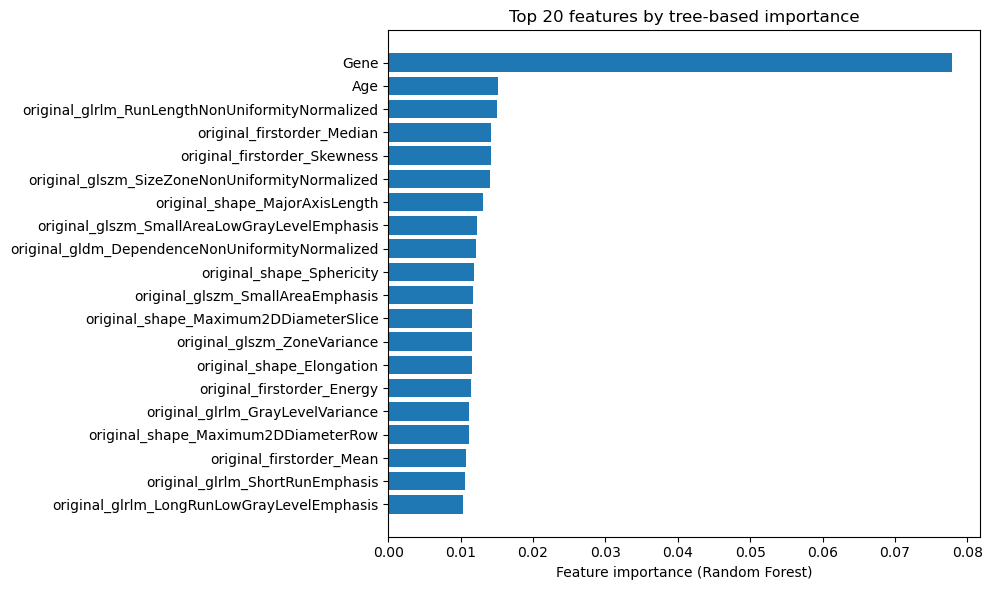

,feature,importance
114,Gene,0.077852
0,Age,0.015203
81,original_glrlm_RunLengthNonUniformityNormalized,0.014965
24,original_firstorder_Median,0.014239
29,original_firstorder_Skewness,0.014215
96,original_glszm_SizeZoneNonUniformityNormalized,0.014049
4,original_shape_MajorAxisLength,0.013039
99,original_glszm_SmallAreaLowGrayLevelEmphasis,0.012246
59,original_gldm_DependenceNonUniformityNormalized,0.012164
11,original_shape_Sphericity,0.011801


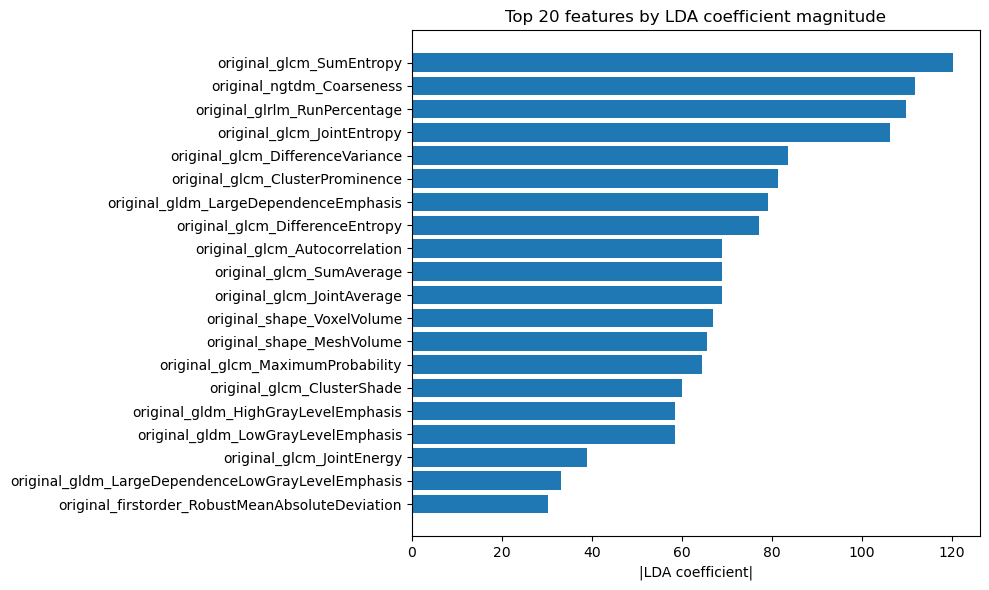

,feature,importance
55,original_glcm_SumEntropy,120.157059
104,original_ngtdm_Coarseness,111.655109
82,original_glrlm_RunPercentage,109.708536
51,original_glcm_JointEntropy,106.211844
41,original_glcm_DifferenceVariance,83.472213
34,original_glcm_ClusterProminence,81.372712
64,original_gldm_LargeDependenceEmphasis,79.145597
40,original_glcm_DifferenceEntropy,77.086193
33,original_glcm_Autocorrelation,68.881793
54,original_glcm_SumAverage,68.853139


In [42]:
# Tree-based and LDA feature importance visualisation
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Use the processed features from Section 1.4
X_feat = X_processed_df.values
feat_names_raw = X_processed_df.columns.tolist()

# Clean the names by stripping the transformer prefixes (num__, cat_nom__, cat_ord__)
feat_names = [
    name.split("__", 1)[1] if "__" in name else name
    for name in feat_names_raw
]

# Random Forest feature importances
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)
rf_clf.fit(X_feat, y)

rf_importances = rf_clf.feature_importances_
rf_importance_df = (
    pd.DataFrame({"feature": feat_names, "importance": rf_importances})
    .sort_values("importance", ascending=False)
)

top_k = 20
top_rf = rf_importance_df.head(top_k)

plt.figure(figsize=(10, 6))
plt.barh(top_rf["feature"][::-1], top_rf["importance"][::-1])
plt.xlabel("Feature importance (Random Forest)")
plt.title(f"Top {top_k} features by tree-based importance")
plt.tight_layout()
plt.show()

display(top_rf)

# LDA feature importance via absolute coefficients
lda_clf = LDA()
lda_clf.fit(X_feat, y)

# For binary pCR, coef_ has shape (1, n_features)
lda_importances = np.abs(lda_clf.coef_[0])
lda_importance_df = (
    pd.DataFrame({"feature": feat_names, "importance": lda_importances})
    .sort_values("importance", ascending=False)
)

top_k_lda = 20
top_lda = lda_importance_df.head(top_k_lda)

plt.figure(figsize=(10, 6))
plt.barh(top_lda["feature"][::-1], top_lda["importance"][::-1])
plt.xlabel("|LDA coefficient|")
plt.title(f"Top {top_k_lda} features by LDA coefficient magnitude")
plt.tight_layout()
plt.show()

display(top_lda)

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

# Define pipelines with different feature selection methods
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor_knn),
    ("rf", ForcedInclusionSelector(
        selector=SelectFromModel(
            RandomForestClassifier(n_estimators=100, random_state=42), 
            threshold=-np.inf,
            max_features=30
        ),
        vital_indices=vital_indices
    )),
])

mi_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor_knn),
    ("mi", ForcedInclusionSelector(
        selector=SelectKBest(score_func=mutual_info_classif, k=30),
        vital_indices=vital_indices
    )),    
])

pca_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor_knn),  
    ("pca", PCA(n_components=30)),     
])

dt_pca_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor_knn),
    ("rf", ForcedInclusionSelector(
        selector=SelectFromModel(
            RandomForestClassifier(n_estimators=100, random_state=42), 
            threshold=-np.inf,
            max_features=30
        ),
        vital_indices=vital_indices
    )),
    ("pca", PCA(n_components=0.95)),
])

mi_pca_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor_knn),
    ("mi", ForcedInclusionSelector(
        selector=SelectKBest(score_func=mutual_info_classif, k=30),
        vital_indices=vital_indices
    )), 
    ("pca", PCA(n_components=0.95)),     
])

pipelines_dict = {
    "PCA": pca_pipeline,
    "MI": mi_pipeline,
    "RF": rf_pipeline,
    "PCA_MI": mi_pca_pipeline,
    "PCA_DT": dt_pca_pipeline,
}

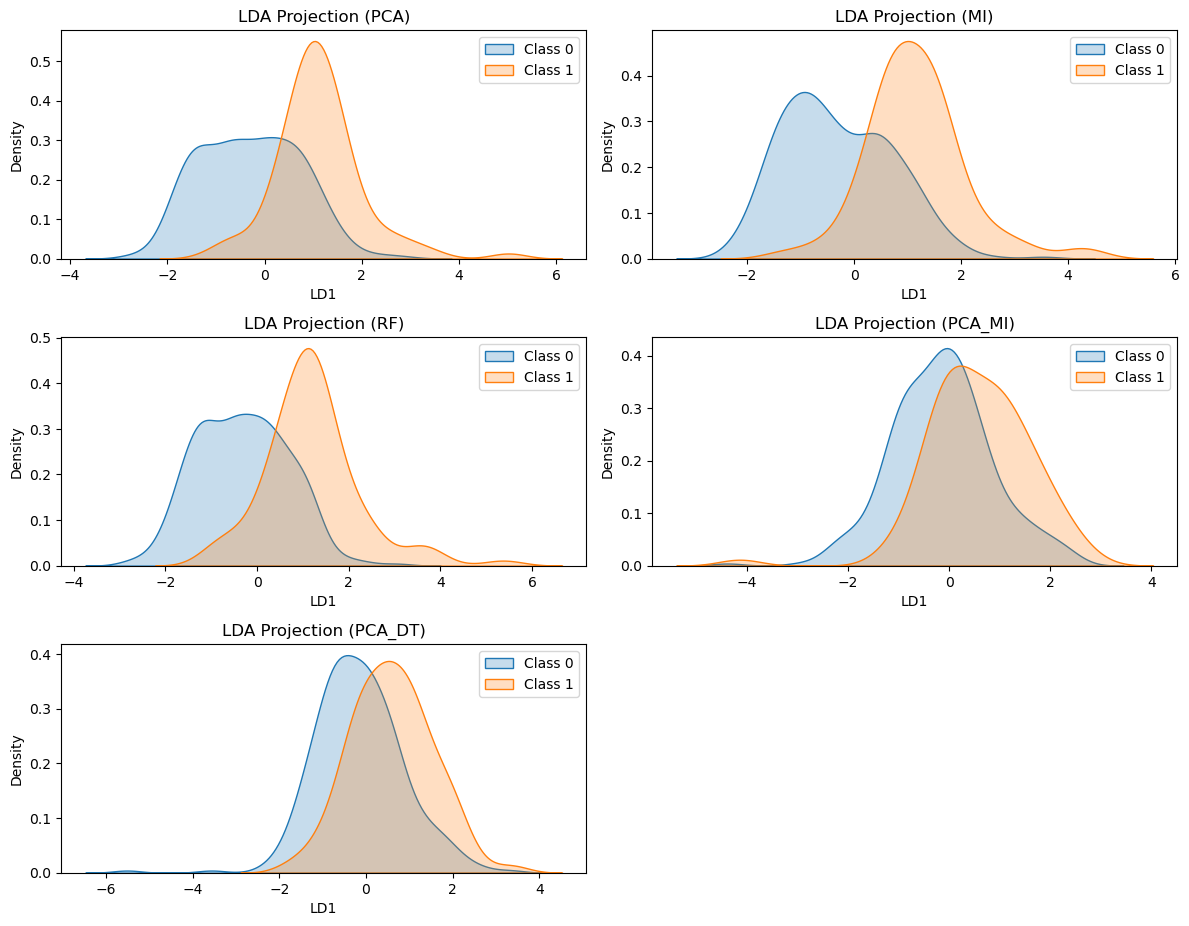

In [44]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

plt.figure(figsize=(12,12))

for i, (pipe_name, pipeline) in enumerate(pipelines_dict.items(), 1):
    # Clone pipeline to avoid modifying the original
    pipe_clone = clone(pipeline)
    
    # Fit-transform through preprocessing + feature selection
    X_transformed = pipe_clone.fit_transform(X, y)
    
    # Apply LDA
    lda = LDA(n_components=1)
    X_lda = lda.fit_transform(X_transformed, y)
    
    # Plot KDE for each class
    plt.subplot(4, 2, i)
    sns.kdeplot(X_lda[y==0].flatten(), label='Class 0', fill=True)
    sns.kdeplot(X_lda[y==1].flatten(), label='Class 1', fill=True)
    plt.title(f"LDA Projection ({pipe_name})")
    plt.xlabel("LD1")
    plt.ylabel("Density")
    plt.legend()

plt.tight_layout()
plt.show()

## 3. Model Selection and Comparison
We project the preprocessed Mutual Information features and compare several classifiers using a train/test split and 5-fold cross-validation. A custom selector was made to ensure the vital clinical and biomarker features were retained.

In [45]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Define models to evaluate
models = {
    "Logistic Regression": LogisticRegression(max_iter=20000, class_weight="balanced", random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "MLP (Neural Net)": MLPClassifier(max_iter=3000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")
}

# Evaluate models
results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_scorer = make_scorer(f1_score, pos_label=1)
balanced_acc_scorer = make_scorer(balanced_accuracy_score)
f1_macro_scorer = make_scorer(f1_score, average='macro')

for name, model in models.items():
    # Fit on training set
    clf = Pipeline(steps=[
        ("preprocess", preprocessor_knn),
        ("mi", ForcedInclusionSelector(
            selector=SelectKBest(score_func=mutual_info_classif, k=30),
            vital_indices=vital_indices
        )), 
        ("model", model)
    ])
    
    clf.fit(X_train, y_train)
    test_acc = clf.score(X_val, y_val)
    
    # Cross-validation on full LDA projection
    cv_acc = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
    cv_f1 = cross_val_score(clf, X, y, cv=skf, scoring=f1_scorer)
    cv_balance = cross_val_score(clf, X, y, cv=skf, scoring=balanced_acc_scorer)
    cv_f1_macro = cross_val_score(clf, X, y, cv=skf, scoring=f1_macro_scorer)
    
    
    results.append({
        "Model": name,
        "Test Accuracy": test_acc,
        "CV Accuracy (mean)": np.mean(cv_acc),
        "CV F1 (mean)": np.mean(cv_f1),
        "CV Balanced Accuracy (mean)": np.mean(cv_balance),
        "CV F1 Macro (mean)": np.mean(cv_f1_macro)
    })

results_df = pd.DataFrame(results).set_index("Model")
results_df

,Test Accuracy,CV Accuracy (mean),CV F1 (mean),CV Balanced Accuracy (mean),CV F1 Macro (mean)
Model,,,,,
Logistic Regression,0.663866,0.713924,0.504140,0.701447,0.635936
SVM (RBF),0.663866,0.675949,0.442419,0.655097,0.602941
Decision Tree,0.714286,0.767089,0.395363,0.590971,0.590764
MLP (Neural Net),0.756303,0.746835,0.385261,0.611025,0.607866
Random Forest,0.798319,0.789873,0.177979,0.529243,0.534987
XGBoost,0.773109,0.789873,0.328293,0.622815,0.623335


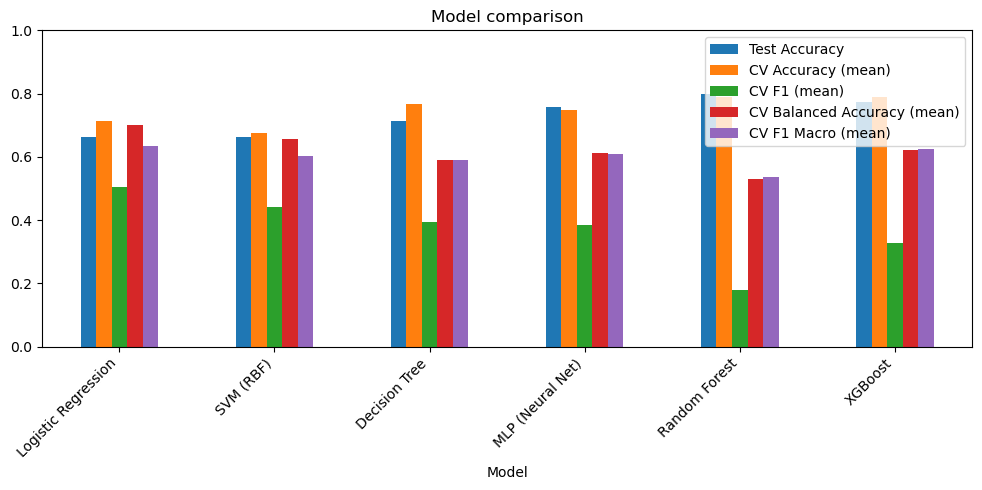

In [47]:
# Plot the results
ax = results_df[["Test Accuracy", "CV Accuracy (mean)", "CV F1 (mean)", "CV Balanced Accuracy (mean)", "CV F1 Macro (mean)"]].plot(
    kind="bar", figsize=(10,5)
)
plt.ylim(0, 1)
plt.title("Model comparison")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observation:** The Logistic Regression achieves the highest cross-validated F1 score, cross-validated Balanced Accuracy Score, and cross-validated F1 Macro score, motivating its selection as the base classifier for the final MI pipeline.

## 4. Final Model: Logistic Regression + MI on Preprocessed Features

We now tune an Logistic Regression classifier within a full pipeline composed of:
1. Preprocessing (KNN-based imputation, scaling, encoding)
2. Mutual Information as feature selection
3. Logistic Regression classifier

In [48]:
# Full pipeline: preprocessing -> MI -> Logistic Regression
log_clf = LogisticRegression(max_iter=40000, class_weight="balanced", random_state=RANDOM_STATE, solver="saga")

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor_knn),
    ("mi", ForcedInclusionSelector(
        selector=SelectKBest(score_func=mutual_info_classif, k=30),
        vital_indices=vital_indices
    )), 
    ("model", log_clf)
])

# Hyperparameter grid (using model__ prefix for pipeline)
param_grid = {
    "mi__selector__k": [15, 25, 30, 35, 45], 
    "model__C": [0.01, 0.1, 1, 10, 25], 
    "model__penalty": ["l1", "l2"], 
    "model__solver": ["saga"],
    "preprocess__cat_nom__imputer__n_neighbors": [3, 5, 7],
    "preprocess__cat_ord__imputer__n_neighbors": [3, 5, 7]
} 

balanced_acc_scorer = make_scorer(balanced_accuracy_score)

In [49]:
# Run GridSearchCV
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    n_jobs=-1,
    scoring=balanced_acc_scorer,
    verbose=2,
    return_train_score=True
)

grid.fit(X_train_raw, y_train)

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
[CV] END mi__selector__k=15, model__C=0.01, model__penalty=l1, model__solver=saga, preprocess__cat_nom__imputer__n_neighbors=3, preprocess__cat_ord__imputer__n_neighbors=3; total time=   0.2s
[CV] END mi__selector__k=15, model__C=0.01, model__penalty=l1, model__solver=saga, preprocess__cat_nom__imputer__n_neighbors=3, preprocess__cat_ord__imputer__n_neighbors=3; total time=   0.1s
[CV] END mi__selector__k=15, model__C=0.01, model__penalty=l1, model__solver=saga, preprocess__cat_nom__imputer__n_neighbors=3, preprocess__cat_ord__imputer__n_neighbors=3; total time=   0.1s
[CV] END mi__selector__k=15, model__C=0.01, model__penalty=l1, model__solver=saga, preprocess__cat_nom__imputer__n_neighbors=3, preprocess__cat_ord__imputer__n_neighbors=3; total time=   0.1s
[CV] END mi__selector__k=15, model__C=0.01, model__penalty=l1, model__solver=saga, preprocess__cat_nom__imputer__n_neighbors=3, preprocess__cat_ord__imputer__n_neighbor

,estimator,Pipeline(step...ver='saga'))])
,param_grid,"{'mi__selector__k': [15, 25, ...], 'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['saga'], ...}"
,scoring,make_scorer(b...hod='predict')
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat_nom', ...), ...]"


In [50]:
# Output best parameters and performance

print("Best parameters:", grid.best_params_)
print(f"Best CV F1: {grid.best_score_:.3f}")

# Evaluate on held-out validation set
best_pipeline = grid.best_estimator_
val_pred = best_pipeline.predict(X_val_raw)
val_acc = accuracy_score(y_val, val_pred)
val_f1 = f1_score(y_val, val_pred, pos_label=1)
val_bal_acc = balanced_accuracy_score(y_val, val_pred)

print(f"Validation Accuracy: {val_acc:.3f}")
print(f"Validation F1: {val_f1:.3f}")
print(f"Validation Balanced Accuracy: {val_bal_acc:.3f}")

Best parameters: {'mi__selector__k': 15, 'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'saga', 'preprocess__cat_nom__imputer__n_neighbors': 5, 'preprocess__cat_ord__imputer__n_neighbors': 7}
Best CV F1: 0.742
Validation Accuracy: 0.689
Validation F1: 0.493
Validation Balanced Accuracy: 0.700


In [51]:
# Final model training on full dataset for submission
final_pipeline = grid.best_estimator_

# Fit on the full training data (X, y)
final_pipeline.fit(X, y)

,steps,"[('preprocess', ...), ('mi', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_nom', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
# Sanity check on example test dataset

test_example = pd.read_csv("../data/TestDatasetExample.csv")
test_example_clean = test_example.replace(999, np.nan)

# Keep same feature columns as X
X_test_example = test_example_clean[X.columns]

y_pred_example = final_pipeline.predict(X_test_example)
pd.Series(y_pred_example).value_counts()

1.0    2
0.0    1
Name: count, dtype: int64

The object `final_pipeline` now encapsulates the complete preprocessing–MI–Logistic Regression workflow for PCR prediction and is used as the basis for the deployment scripts (`TrainPCRModel.py` and `FinalTestPCR.py`).

In [53]:
import joblib
import os

# Ensure models directory exists
os.makedirs("models", exist_ok=True)
model_path = os.path.join("models", "pcr_final_model.pkl")


# Save trained pipeline
joblib.dump(final_pipeline, model_path)
print("Model saved successfully!")

Model saved successfully!
